In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import joblib
print('libraries loaded')

libraries loaded


In [ ]:
url = "https://huggingface.co/datasets/unifyair/mobility_data/resolve/main/balanced_data.parquet"
df = pd.read_parquet(url)
print(df.shape)
df.head()

(301752, 18)


,timestamp,user_id,x,y,velocity,heading,connected_cell,signal_strength,handover_needed,handover_target,pattern_type,hour,network_load,sinr,throughput_mbps,device_type,handover_latency,handover_success
1166400,2025-04-21 23:23:12.474562,user_45,6296.465637,5474.285214,1.335849,4.793299,cell_6_5,-84.953200,True,cell_7_6,random_walk,23,0.494111,-94.453279,NaN,5G_basic,24.982918,True
440640,2025-04-21 23:23:12.474562,user_17,546.220385,5580.758893,12.343482,0.983552,cell_1_6,-85.816983,True,cell_0_6,high_mobility,23,0.475454,-95.391321,NaN,5G_advanced,12.606831,True
1892160,2025-04-21 23:23:12.474562,user_73,5596.156555,2584.968459,0.626970,1.999647,cell_6_3,-85.254863,True,cell_6_2,random_walk,23,0.437518,-91.927482,NaN,5G_basic,10.917309,True
492480,2025-04-21 23:23:12.474562,user_19,6559.466306,3464.381437,21.475465,2.643567,cell_7_3,-86.124872,True,cell_6_4,high_mobility,23,0.393944,-94.922396,NaN,5G_basic,27.411426,True
570240,2025-04-21 23:23:12.474562,user_22,2386.607973,7477.079360,28.210266,1.193440,cell_2_7,-85.764225,True,cell_3_8,high_mobility,23,0.390981,-86.593457,NaN,5G_premium,11.265609,True


In [ ]:
print(df['handover_needed'].value_counts())
print(df['handover_success'].value_counts())
print(df.isnull().sum())
print(df.dtypes)

handover_needed
False    226314
True      75438
Name: count, dtype: int64
handover_success
True     286756
False     14996
Name: count, dtype: int64
timestamp                0
user_id                  0
x                        0
y                        0
velocity                 0
heading                  0
connected_cell           0
signal_strength          0
handover_needed          0
handover_target     226314
pattern_type             0
hour                     0
network_load             0
sinr                     0
throughput_mbps     301747
device_type              0
handover_latency         0
handover_success         0
dtype: int64
timestamp           datetime64[ns]
user_id                     object
x                          float64
y                          float64
velocity                   float64
heading                    float64
connected_cell              object
signal_strength            float64
handover_needed               bool
handover_target             object
pa

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('training complete')

training complete


In [ ]:
df['pattern_type'] = df['pattern_type'].astype(str)
df['connected_cell'] = df['connected_cell'].astype(str)
df['handover_target'] = df['handover_target'].fillna('none').astype(str)
df['device_type'] = df['device_type'].astype(str)
le_pattern = LabelEncoder()
df['pattern_type_enc'] = le_pattern.fit_transform(df['pattern_type'])
le_cell = LabelEncoder()
df['connected_cell_enc'] = le_cell.fit_transform(df['connected_cell'])
le_device = LabelEncoder()
df['device_type_enc'] = le_device.fit_transform(df['device_type'])
feature_cols = ['x', 'y', 'velocity', 'heading', 'signal_strength', 'sinr', 'network_load', 'hour', 'pattern_type_enc', 'connected_cell_enc', 'device_type_enc']
X = df[feature_cols]
y = df['handover_needed'].astype(int)
print(X.shape, y.shape)
print(X.isnull().sum())

(301752, 11) (301752,)
x                     0
y                     0
velocity              0
heading               0
signal_strength       0
sinr                  0
network_load          0
hour                  0
pattern_type_enc      0
connected_cell_enc    0
device_type_enc       0
dtype: int64


In [ ]:
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
print('Logistic Regression:')
print(classification_report(y_test, y_pred_log))
print('Random Forest:')
print(classification_report(y_test, y_pred_rf))
print('RF ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87     45263
           1       0.61      0.38      0.47     15088

    accuracy                           0.78     60351
   macro avg       0.71      0.65      0.67     60351
weighted avg       0.77      0.78      0.77     60351

Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     45263
           1       0.89      0.86      0.87     15088

    accuracy                           0.94     60351
   macro avg       0.92      0.91      0.92     60351
weighted avg       0.94      0.94      0.94     60351

RF ROC-AUC: 0.9801124970184272


In [ ]:
)

In [ ]:
df_clean = df.drop_duplicates().copy()
print('duplicates removed:', len(df) - len(df_clean))
for col in ['velocity', 'signal_strength', 'sinr', 'network_load']: df_clean[col] = df_clean[col].clip(df_clean[col].quantile(0.01), df_clean[col].quantile(0.99))
df_clean = df_clean[df_clean['hour'].between(0, 23)]
print('rows after cleaning:', len(df_clean), 'of', len(df))

duplicates removed: 0
rows after cleaning: 301752 of 301752


signal_strength       0.592388
y                     0.134716
x                     0.109208
sinr                  0.067150
velocity              0.036892
connected_cell_enc    0.036849
pattern_type_enc      0.010310
network_load          0.004867
heading               0.004415
hour                  0.002644
device_type_enc       0.000559
dtype: float64


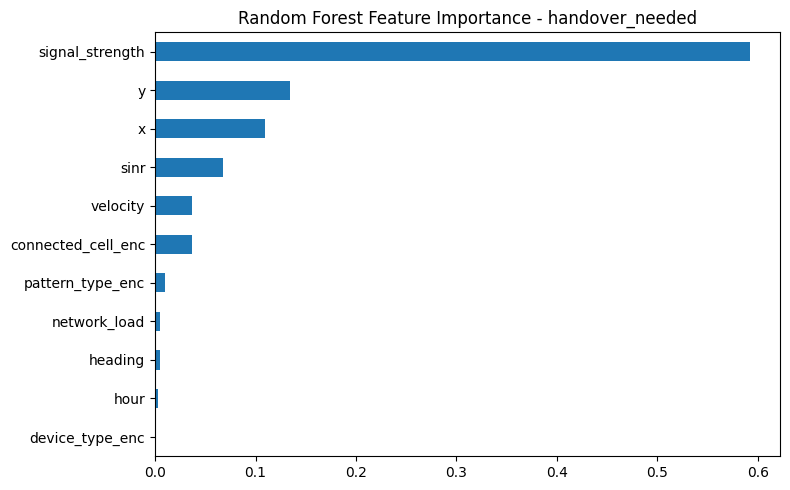

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)
plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance - handover_needed')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [ ]:
n = df.drop_duplicates().copy(
  print('duplicates removed:', len(df) - len(df_clean))
  for col in ['velocity', 'signal_strength', 'sinr', 'network_load']: df_clean[col] = df_clean[col].clip(df_clean[col].quantile(0.01), df_clean[col].quantile(0.99))
  df_clean = df_clean[df_clean['hour'].between(0, 23)]
  print('rows after cleaning:', len(df_clean), 'of', len(df))

In [ ]:
joblib.dump(rf, 'echo_handover_rf_model.joblib')
joblib.dump(scaler, 'echo_scaler.joblib')
joblib.dump(le_pattern, 'echo_le_pattern.joblib')
joblib.dump(le_cell, 'echo_le_cell.joblib')
joblib.dump(le_device, 'echo_le_device.joblib')
print('model + preprocessors saved')

model + preprocessors saved


In [ ]:
df_clean['hour_sin'] = np.sin(2*np.pi*df_clean['hour']/24)
df_clean['hour_cos'] = np.cos(2*np.pi*df_clean['hour']/24)
df_clean['vx'] = df_clean['velocity']*np.cos(df_clean['heading'])
df_clean['vy'] = df_clean['velocity']*np.sin(df_clean['heading'])
cell_centers = df_clean.groupby('connected_cell')[['x','y']].transform('mean')
df_clean['dist_to_cell_center'] = np.sqrt((df_clean['x']-cell_centers['x'])**2 + (df_clean['y']-cell_centers['y'])**2)
df_clean['signal_sinr_ratio'] = df_clean['signal_strength'] / df_clean['sinr']
df_clean['load_x_velocity'] = df_clean['network_load'] * df_clean['velocity']
print('engineered features added')

engineered features added


In [ ]:
df_clean['pattern_type'] = df_clean['pattern_type'].astype(str)
df_clean['connected_cell'] = df_clean['connected_cell'].astype(str)
df_clean['device_type'] = df_clean['device_type'].astype(str)
le_pattern2 = LabelEncoder()
df_clean['pattern_type_enc'] = le_pattern2.fit_transform(df_clean['pattern_type'])
le_cell2 = LabelEncoder()
df_clean['connected_cell_enc'] = le_cell2.fit_transform(df_clean['connected_cell'])
le_device2 = LabelEncoder()
df_clean['device_type_enc'] = le_device2.fit_transform(df_clean['device_type'])
feature_cols2 = ['x', 'y', 'velocity', 'heading', 'signal_strength', 'sinr', 'network_load', 'hour', 'hour_sin', 'hour_cos', 'vx', 'vy', 'dist_to_cell_center', 'signal_sinr_ratio', 'load_x_velocity', 'pattern_type_enc', 'connected_cell_enc', 'device_type_enc']
X2 = df_clean[feature_cols2]
y2 = df_clean['handover_needed'].astype(int)
print(X2.shape, y2.shape, X2.isnull().sum().sum())

(301752, 18) (301752,) 0


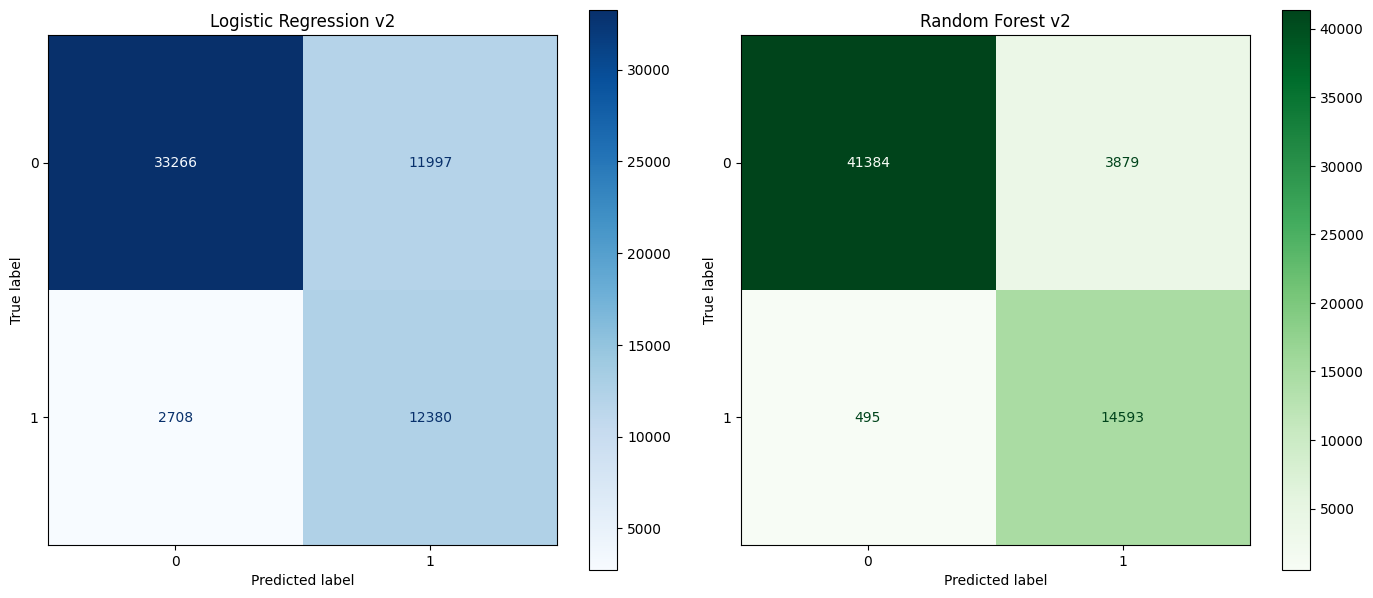

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14,6))
ConfusionMatrixDisplay.from_predictions(y2_test, y2_pred_log, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression v2')
ConfusionMatrixDisplay.from_predictions(y2_test, y2_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest v2')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

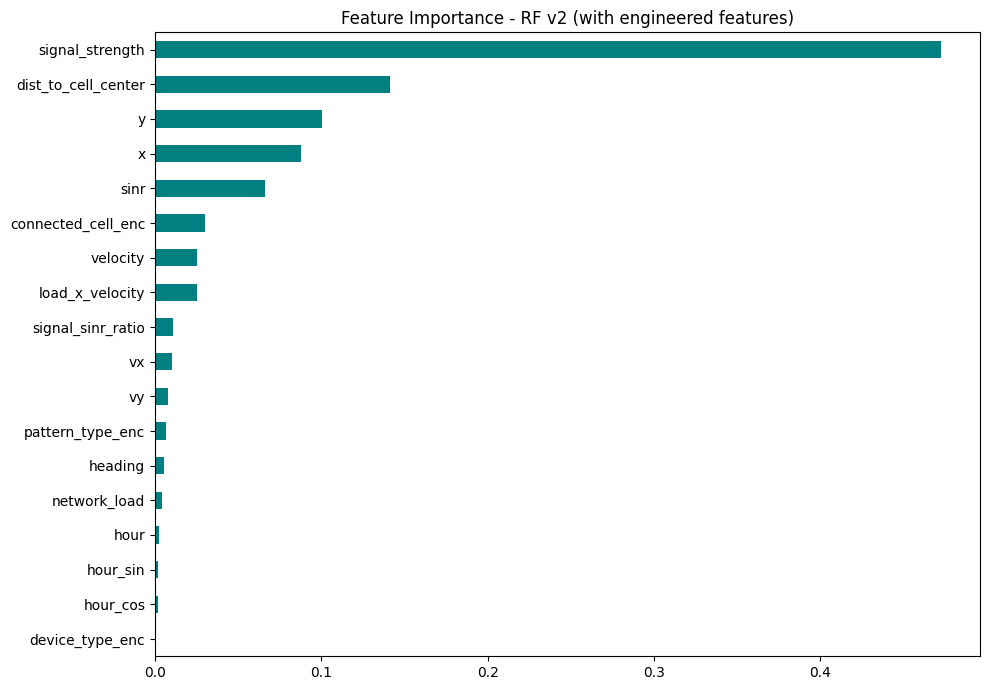

signal_strength        0.472424
dist_to_cell_center    0.141179
y                      0.100136
x                      0.087458
sinr                   0.066282
connected_cell_enc     0.030167
velocity               0.025363
load_x_velocity        0.025187
signal_sinr_ratio      0.010549
vx                     0.010290
vy                     0.008015
pattern_type_enc       0.006437
heading                0.005111
network_load           0.004298
hour                   0.002336
hour_sin               0.002016
hour_cos               0.001938
device_type_enc        0.000814
dtype: float64


In [ ]:

importances2 = pd.Series(rf2.feature_importances_, index=feature_cols2).sort_values(ascending=False)
plt.figure(figsize=(10,7))
importances2.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Feature Importance - RF v2 (with engineered features)')
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150)
plt.show()
print(importances2)

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)
log_reg2 = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg2.fit(X2_train_scaled, y2_train)
rf2 = RandomForestClassifier(n_estimators=300, max_depth=18, min_samples_leaf=2, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
print('training v2 complete')

training v2 complete


In [ ]:

from sklearn.metrics import f1_score
y2_pred_log = log_reg2.predict(X2_test_scaled)
y2_pred_rf = rf2.predict(X2_test)
print('--- Logistic Regression v2 ---')
print(classification_report(y2_test, y2_pred_log))
print('F1:', f1_score(y2_test, y2_pred_log), 'ROC-AUC:', roc_auc_score(y2_test, log_reg2.predict_proba(X2_test_scaled)[:,1]))
print('--- Random Forest v2 ---')
print(classification_report(y2_test, y2_pred_rf))
print('F1:', f1_score(y2_test, y2_pred_rf), 'ROC-AUC:', roc_auc_score(y2_test, rf2.predict_proba(X2_test)[:,1]))
print('Accuracy RF v2:', accuracy_score(y2_test, y2_pred_rf))

--- Logistic Regression v2 ---
              precision    recall  f1-score   support

           0       0.92      0.73      0.82     45263
           1       0.51      0.82      0.63     15088

    accuracy                           0.76     60351
   macro avg       0.72      0.78      0.72     60351
weighted avg       0.82      0.76      0.77     60351

F1: 0.6273913594324084 ROC-AUC: 0.8586973448849401
--- Random Forest v2 ---
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     45263
           1       0.79      0.97      0.87     15088

    accuracy                           0.93     60351
   macro avg       0.89      0.94      0.91     60351
weighted avg       0.94      0.93      0.93     60351

F1: 0.8696662693682956 ROC-AUC: 0.9804195564094368
Accuracy RF v2: 0.927523984689566


In [ ]:
joblib.dump(rf2, 'echo_handover_rf_model_v2.joblib')
joblib.dump(scaler2, 'echo_scaler_v2.joblib')
joblib.dump(le_pattern2, 'echo_le_pattern_v2.joblib')
joblib.dump(le_cell2, 'echo_le_cell_v2.joblib')
joblib.dump(le_device2, 'echo_le_device_v2.joblib')
print('v2 model + preprocessors saved')
print('--- v1 vs v2 comparison ---')
print('v1 RF (11 features, no cleaning): accuracy=0.94, ROC-AUC=0.98')
print('v2 RF (18 features, cleaned, balanced_subsample):', 'accuracy=', accuracy_score(y2_test, y2_pred_rf), 'F1=', f1_score(y2_test, y2_pred_rf), 'ROC-AUC=', roc_auc_score(y2_test, rf2.predict_proba(X2_test)[:,1]))

v2 model + preprocessors saved
--- v1 vs v2 comparison ---
v1 RF (11 features, no cleaning): accuracy=0.94, ROC-AUC=0.98
v2 RF (18 features, cleaned, balanced_subsample): accuracy= 0.927523984689566 F1= 0.8696662693682956 ROC-AUC= 0.9804195564094368
